In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0.0, 15.0, 2000)

In [2]:
# =====================================================
# Figure 1: original PX4 shapes (Set 1)
# =====================================================

def set1_spiral(t):
    R, T = 2.0, 7.5
    x = R * np.sin(2*np.pi*t/T)
    y = R * np.cos(2*np.pi*t/T)
    z = -3.0 * np.ones_like(t)
    return x, y, z

def set1_figure_eight(t):
    R, T = 2.0, 10.0
    x = R * np.sin(2*np.pi*t/T)
    y = R * np.sin(4*np.pi*t/T) / 2.0
    z = -3.0 * np.ones_like(t)
    return x, y, z

def set1_trefoil(t):
    R, T = 1.0, 15.0
    s = 2*np.pi*t/T
    x = R * (np.sin(s) + 2*np.sin(2*s))
    y = R * (np.cos(s) - 2*np.cos(2*s))
    z = -3.0 + 0.4 * (-np.sin(3*s))
    return x, y, z

def set1_fig8_heading(t):
    R, T = 1.5, 15.0
    s = 2*np.pi*t/T
    x = R * np.sin(s)
    y = R * np.sin(2*s) / 2.0
    z = -3.0 * np.ones_like(t)
    return x, y, z

set1_trajs = [
    ("Spiral", set1_spiral),
    ("Figure Eight", set1_figure_eight),
    ("Trefoil", set1_trefoil),
    ("Fig8 Heading", set1_fig8_heading),
]

In [3]:
# =====================================================
# Figure 2: updated PX4 shapes (Set 2 replacement)
# =====================================================

def set2_figure_eight(t):
    height = 3.0
    R, T = 5.0, 10.0
    x = R * np.sin(2*np.pi*t/T)
    y = R * np.sin(4*np.pi*t/T) / 2.0
    z = -height * np.ones_like(t)
    return x, y, z

def set2_fig8_heading(t):
    height = 3.0
    R, T = 3.0, 15.0
    s = 2*np.pi*t/T
    x = R * np.sin(s)
    y = R * np.sin(2*s) / 2.0
    z = -height * np.ones_like(t)
    return x, y, z

def set2_spiral(t):
    h_low = 1.5
    h_high = 3.0
    R = 5.0

    cycle_time = 15.0
    num_turns = 2.0

    t_cycle = np.mod(t, cycle_time)
    T_half = cycle_time / 2.0

    up_mask = t_cycle <= T_half

    # normalized branch progress in [0, 1]
    tau_up = t_cycle / T_half
    tau_down = (t_cycle - T_half) / T_half

    # height: up then back down
    z_height_up = h_low + (h_high - h_low) * tau_up
    z_height_down = h_high - (h_high - h_low) * tau_down
    z_height = np.where(up_mask, z_height_up, z_height_down)

    # angle: forward on the way up, reversed on the way down
    theta_up = 2.0 * np.pi * num_turns * tau_up
    theta_down = 2.0 * np.pi * num_turns * (1.0 - tau_down)
    theta = np.where(up_mask, theta_up, theta_down)

    x = R * np.cos(theta)
    y = R * np.sin(theta)
    z = -z_height

    return x, y, z

def set2_trefoil(t):
    T = 15.0
    R = 2.0
    s = 2*np.pi*t/T

    h_low = 1.5
    h_high = 3.0
    h_mid = 0.5 * (h_low + h_high)
    h_amp = 0.5 * (h_high - h_low)

    x = R * (np.sin(s) + 2*np.sin(2*s))
    y = R * (np.cos(s) - 2*np.cos(2*s))
    z = -(h_mid + h_amp * np.sin(3*s))
    return x, y, z

set2_trajs = [
    ("Spiral", set2_spiral),
    ("Figure Eight", set2_figure_eight),
    ("Trefoil", set2_trefoil),
    ("Fig8 Heading", set2_fig8_heading),
]


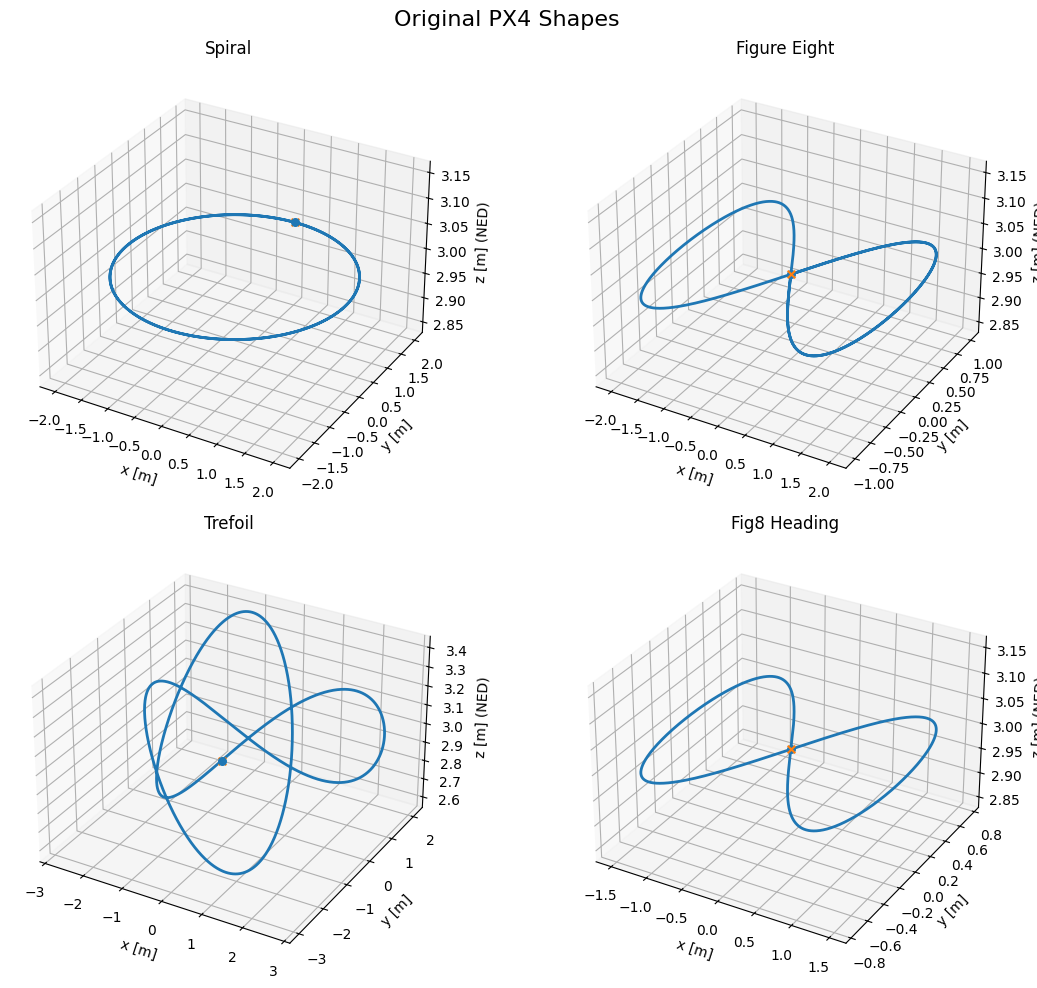

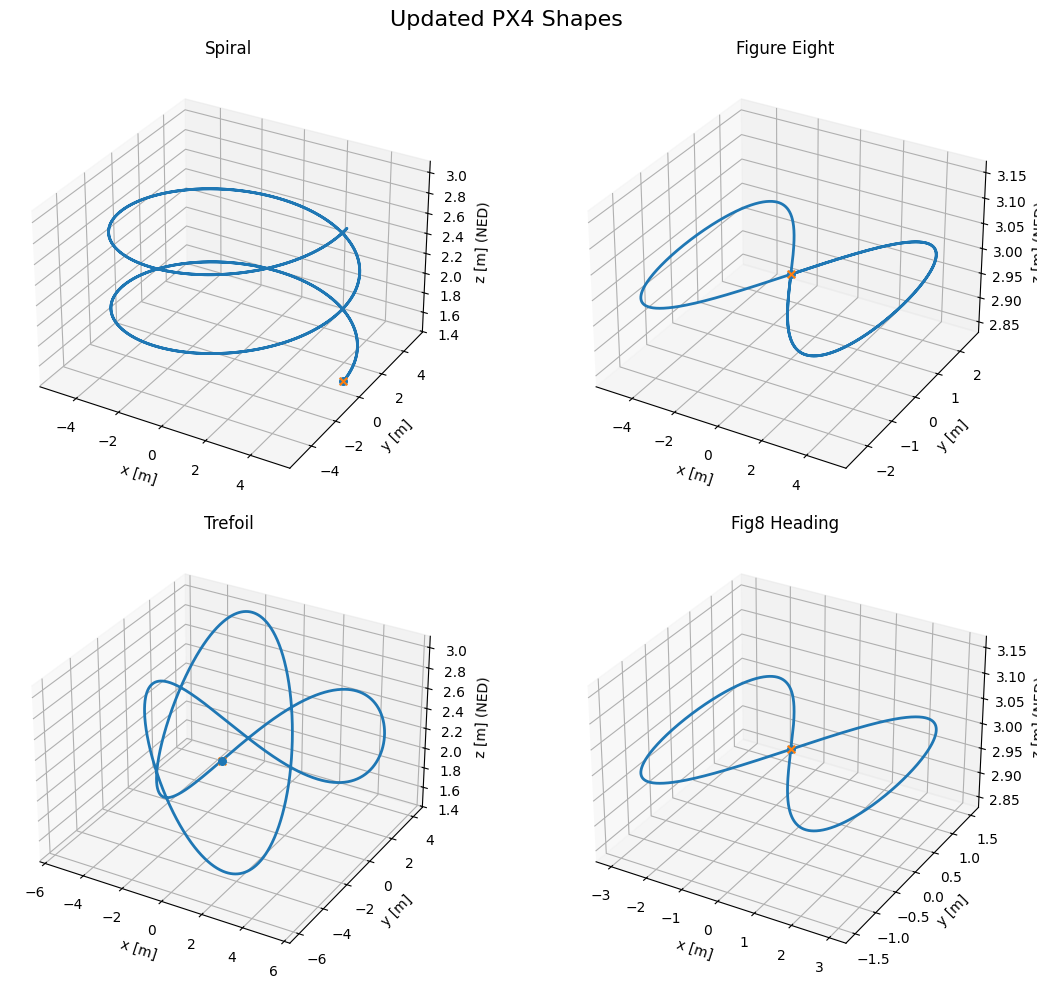

In [4]:
def plot_figure_grid(trajs, fig_title):
    fig = plt.figure(figsize=(12, 10))
    for i, (title, fn) in enumerate(trajs, start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")
        x, y, z = fn(t)
        ax.plot(x, y, -z, linewidth=2)
        ax.scatter(x[0], y[0], -z[0], s=30, label="start")
        ax.scatter(x[-1], y[-1], -z[-1], s=30, marker="x", label="end")
        ax.set_title(title)
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.set_zlabel("z [m] (NED)")
        ax.set_box_aspect((1, 1, 0.7))
        ax.grid(True)
    fig.suptitle(fig_title, fontsize=16)
    fig.tight_layout()
    plt.show()

plot_figure_grid(set1_trajs, "Original PX4 Shapes")
plot_figure_grid(set2_trajs, "Updated PX4 Shapes")